# Tutorial: ACLED Gaza best-fit 2-week rolling forecasts

This notebook looks for the strongest forecasting recipe available with the current `motac` codebase.

We keep the task fixed:

- Gaza ACLED snapshot
- 14-day bins
- rolling 1-step-ahead forecasts
- masked evaluation inside the Gaza polygon

We compare:

- a light Poisson MAP reference
- a tuned NB2 MAP ensemble
- NB2 SVI on the same task
- a tuned hybrid road prior
- `nuts_small` on the tiny early splits where `motac` allows it

The goal is practical: identify the best full-task recipe and show where the alternative inference backends help or fail.

In [1]:
import gc
import time
NB_START = time.perf_counter()

import json
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.path import Path as MplPath

from motac import (
    EdgeList,
    EventTable,
    FitConfig,
    GridSpec,
    HawkesModelSpec,
    MobilityHawkesModel,
    acled_to_counts,
)
from motac.connectivity import make_grid_edgelist, make_grid_stencil
from motac.eval import score_crps_counts, score_predictive_log_prob_samples

plt.style.use("seaborn-v0_8-whitegrid")

DATA_DIR = Path("docs/tutorials/data")
if not DATA_DIR.exists():
    DATA_DIR = Path("data")

print("JAX backend:", jax.default_backend())
print("Devices:", jax.devices())

JAX backend: gpu
Devices: [CudaDevice(id=0)]


## Load the Gaza snapshot and build the 2-week tensor

We use the same local ACLED snapshot and Gaza polygon cache as the earlier tutorials.

The modelling tensor keeps the top four grouped event types, uses an approximately 1 km grid, and bins time into 14-day intervals.

In [2]:
snapshot_path = DATA_DIR / "acled_events_example.csv"
if not snapshot_path.exists():
    raise FileNotFoundError(f"Missing snapshot: {snapshot_path}")

GAZA_BOUNDARY_CACHE = DATA_DIR / "gaza_boundary.geojson"
ROAD_SEGMENTS_CACHE = DATA_DIR / "gaza_osm_roads_segments.csv"
DEFAULT_GAZA_BBOX = (34.2, 34.6, 31.2, 31.6)
ROAD_REQUIRED_COLS = ["lon0", "lat0", "lon1", "lat1", "highway"]


def close_ring(coords: np.ndarray) -> np.ndarray:
    arr = np.asarray(coords, dtype=float)
    if arr.ndim != 2 or arr.shape[1] != 2:
        raise ValueError("Polygon coordinates must have shape [N, 2].")
    if len(arr) < 3:
        raise ValueError("Polygon ring must contain at least 3 coordinates.")
    if not np.allclose(arr[0], arr[-1]):
        arr = np.vstack([arr, arr[0]])
    return arr


def ring_area(coords: np.ndarray) -> float:
    arr = close_ring(coords)
    x = arr[:, 0]
    y = arr[:, 1]
    return 0.5 * abs(np.dot(x[:-1], y[1:]) - np.dot(y[:-1], x[1:]))


def extract_outer_ring(geometry: dict[str, object]) -> np.ndarray:
    geom_type = geometry.get("type")
    coords = geometry.get("coordinates")

    if geom_type == "Polygon":
        if not coords:
            raise ValueError("Polygon geometry contains no coordinates.")
        return close_ring(np.asarray(coords[0], dtype=float))

    if geom_type == "MultiPolygon":
        if not coords:
            raise ValueError("MultiPolygon geometry contains no coordinates.")
        rings = [close_ring(np.asarray(poly[0], dtype=float)) for poly in coords if poly]
        if not rings:
            raise ValueError("MultiPolygon geometry contains no polygon rings.")
        return max(rings, key=ring_area)

    raise ValueError(f"Unsupported boundary geometry type: {geom_type}")


def load_gaza_outline(boundary_path: Path, fallback_bbox: tuple[float, float, float, float]) -> np.ndarray:
    if boundary_path.exists():
        payload = json.loads(boundary_path.read_text())
        features = payload.get("features", [])
        if not features:
            raise ValueError(f"Boundary cache exists but contains no features: {boundary_path}")
        return extract_outer_ring(features[0]["geometry"])

    lon_min, lon_max, lat_min, lat_max = fallback_bbox
    return close_ring(
        np.array(
            [
                [lon_min, lat_min],
                [lon_max, lat_min],
                [lon_max, lat_max],
                [lon_min, lat_max],
            ],
            dtype=float,
        )
    )


def collapse_event_type(value: object) -> str:
    text = str(value)
    if text == "Explosions/Remote violence":
        return "Explosion"
    if text == "Battles":
        return "Battle"
    if text in {"Riots", "Protests"}:
        return "Riot/Protest"
    if text == "Violence against civilians":
        return "VAC"
    return "Other"


gaza_outline_lonlat = load_gaza_outline(GAZA_BOUNDARY_CACHE, DEFAULT_GAZA_BBOX)
gaza_path_lonlat = MplPath(gaza_outline_lonlat)
GAZA_BBOX = (
    float(gaza_outline_lonlat[:, 0].min()),
    float(gaza_outline_lonlat[:, 0].max()),
    float(gaza_outline_lonlat[:, 1].min()),
    float(gaza_outline_lonlat[:, 1].max()),
)

EARTH_RADIUS_M = 6_371_000.0
center_lon = 0.5 * (GAZA_BBOX[0] + GAZA_BBOX[1])
center_lat = 0.5 * (GAZA_BBOX[2] + GAZA_BBOX[3])
cos_center_lat = np.cos(np.deg2rad(center_lat))


def lonlat_to_local_xy(lon: np.ndarray | float, lat: np.ndarray | float) -> tuple[np.ndarray, np.ndarray]:
    lon_arr = np.asarray(lon, dtype=float)
    lat_arr = np.asarray(lat, dtype=float)
    x = np.deg2rad(lon_arr - center_lon) * EARTH_RADIUS_M * cos_center_lat
    y = np.deg2rad(lat_arr - center_lat) * EARTH_RADIUS_M
    return x, y


def local_xy_to_lonlat(x: np.ndarray | float, y: np.ndarray | float) -> tuple[np.ndarray, np.ndarray]:
    x_arr = np.asarray(x, dtype=float)
    y_arr = np.asarray(y, dtype=float)
    lon = center_lon + np.rad2deg(x_arr / (EARTH_RADIUS_M * max(cos_center_lat, 1e-8)))
    lat = center_lat + np.rad2deg(y_arr / EARTH_RADIUS_M)
    return lon, lat


_df_raw = pd.read_csv(snapshot_path, low_memory=False)
required_cols = {"event_date", "latitude", "longitude", "event_type"}
missing = required_cols - set(_df_raw.columns)
if missing:
    raise ValueError(f"ACLED snapshot missing required columns: {sorted(missing)}")

df = _df_raw.copy()
df["event_date"] = pd.to_datetime(df["event_date"], errors="coerce").dt.floor("D")
df = df.dropna(subset=["event_date", "latitude", "longitude", "event_type"]).copy()
df = df[
    df["longitude"].between(GAZA_BBOX[0], GAZA_BBOX[1])
    & df["latitude"].between(GAZA_BBOX[2], GAZA_BBOX[3])
].copy()

if not df.empty:
    inside_gaza = gaza_path_lonlat.contains_points(
        df[["longitude", "latitude"]].to_numpy(dtype=float),
        radius=1e-9,
    )
    df = df.loc[inside_gaza].copy()

window_start = df["event_date"].max() - pd.Timedelta(days=730)
df = df[df["event_date"] >= window_start].copy()
df["event_type_group"] = df["event_type"].map(collapse_event_type)
top_marks = df["event_type_group"].value_counts().head(4).index.tolist()
df = df[df["event_type_group"].isin(top_marks)].copy().sort_values("event_date").reset_index(drop=True)

proj_x, proj_y = lonlat_to_local_xy(
    df["longitude"].to_numpy(dtype=float),
    df["latitude"].to_numpy(dtype=float),
)
df_model = df.rename(columns={"event_type_group": "event_type_model"}).copy()
df_model["x_proj"] = proj_x
df_model["y_proj"] = proj_y

gaza_outline_x, gaza_outline_y = lonlat_to_local_xy(gaza_outline_lonlat[:, 0], gaza_outline_lonlat[:, 1])
gaza_outline_xy = np.column_stack([gaza_outline_x, gaza_outline_y])
gaza_path_xy = MplPath(gaza_outline_xy)
x_min = float(gaza_outline_xy[:, 0].min())
x_max = float(gaza_outline_xy[:, 0].max())
y_min = float(gaza_outline_xy[:, 1].min())
y_max = float(gaza_outline_xy[:, 1].max())
projected_extent = (x_min, x_max, y_min, y_max)

cell_size_m = 1_000.0
n_cols = max(1, int(np.ceil((x_max - x_min) / cell_size_m)))
n_rows = max(1, int(np.ceil((y_max - y_min) / cell_size_m)))
grid = GridSpec(shape=(n_rows, n_cols), extent=projected_extent, crs="LOCAL_GAZA_EQUIRECT_M")
H, W = grid.shape
num_nodes = H * W

x_edges = np.linspace(x_min, x_max, W + 1)
y_edges = np.linspace(y_min, y_max, H + 1)
x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])
grid_xx, grid_yy = np.meshgrid(x_centers, y_centers, indexing="xy")
gaza_mask = gaza_path_xy.contains_points(
    np.column_stack([grid_xx.reshape(-1), grid_yy.reshape(-1)]),
    radius=1e-9,
).reshape(H, W)
gaza_mask_flat = gaza_mask.reshape(-1)

events = EventTable(
    df=df_model,
    time_col="event_date",
    lat_col="y_proj",
    lon_col="x_proj",
    mark_col="event_type_model",
)
counts_base = acled_to_counts(events, grid, marks=top_marks, dt_days=14)
counts_agnostic = counts_base.with_connectivity(make_grid_stencil(kind="gaussian", size=3, sigma=1.0))

preview_splits = counts_agnostic.rolling_origin_splits(horizon=1, step=1, min_train=2)

print("Rows after Gaza filter:", len(df))
print("Marks:", counts_agnostic.marks)
print("Tensor shape [T, J, M]:", counts_agnostic.y.shape)
print("Grid shape:", grid.shape)
print("Cells inside Gaza mask:", int(gaza_mask.sum()), "/", int(gaza_mask.size))
print("Rolling splits with min_train=2:", len(preview_splits))

Rows after Gaza filter: 15561
Marks: ('Explosion', 'Battle', 'Other', 'VAC')
Tensor shape [T, J, M]: (33, 1428, 4)
Grid shape: (42, 34)
Cells inside Gaza mask: 388 / 1428
Rolling splits with min_train=2: 31


## Helpers for masked scoring and road-aware variants

The built-in rolling backtest is useful, but for this notebook we also want masked Gaza-only metrics and fit diagnostics such as the posterior excitation spectral radius.

In [3]:
def draw_gaza_outline_projected(ax, *, color: str = "black", linewidth: float = 1.0, alpha: float = 0.95) -> None:
    ax.plot(gaza_outline_xy[:, 0], gaza_outline_xy[:, 1], color=color, linewidth=linewidth, alpha=alpha)


def apply_gaza_mask(arr_2d: np.ndarray) -> np.ndarray:
    masked = np.asarray(arr_2d, dtype=float).copy()
    masked[~gaza_mask] = np.nan
    return masked


def flatten_masked_counts(y: np.ndarray) -> np.ndarray:
    arr = np.asarray(y)
    if arr.ndim == 3:
        return arr[:, gaza_mask_flat, :]
    if arr.ndim == 4:
        return arr[:, :, gaza_mask_flat, :]
    raise ValueError(f"Unexpected tensor rank: {arr.ndim}")


def safe_corr(a: np.ndarray, b: np.ndarray) -> float:
    a_flat = np.asarray(a, dtype=float).reshape(-1)
    b_flat = np.asarray(b, dtype=float).reshape(-1)
    finite = np.isfinite(a_flat) & np.isfinite(b_flat)
    if finite.sum() < 2:
        return float("nan")
    a_use = a_flat[finite]
    b_use = b_flat[finite]
    if np.std(a_use) < 1e-8 or np.std(b_use) < 1e-8:
        return float("nan")
    return float(np.corrcoef(a_use, b_use)[0, 1])


def cleanup_memory() -> None:
    gc.collect()
    jax.clear_caches()


def projected_to_node(x: float, y: float) -> int:
    rr = int(np.clip(((y - y_min) / max(y_max - y_min, 1e-8)) * H, 0, H - 1))
    cc = int(np.clip(((x - x_min) / max(x_max - x_min, 1e-8)) * W, 0, W - 1))
    return rr * W + cc


def dict_to_edgelist(weight_map: dict[tuple[int, int], float], *, meta: dict[str, object]) -> EdgeList:
    triples = [(src, dst, weight) for (src, dst), weight in weight_map.items() if weight > 0.0]
    src = np.asarray([t[0] for t in triples], dtype=np.int32)
    dst = np.asarray([t[1] for t in triples], dtype=np.int32)
    weight = np.asarray([t[2] for t in triples], dtype=np.float32)
    row_sum = np.bincount(src, weights=weight, minlength=num_nodes).astype(np.float32)
    weight = weight / np.clip(row_sum[src], 1e-8, None)
    return EdgeList(
        src=jnp.asarray(src),
        dst=jnp.asarray(dst),
        weight=jnp.asarray(weight),
        num_nodes=num_nodes,
        meta=meta,
    )


def edgelist_to_dict(edges: EdgeList) -> dict[tuple[int, int], float]:
    out: dict[tuple[int, int], float] = {}
    for src, dst, weight in zip(np.asarray(edges.src), np.asarray(edges.dst), np.asarray(edges.weight)):
        key = (int(src), int(dst))
        out[key] = out.get(key, 0.0) + float(weight)
    return out


def build_masked_local_graph() -> EdgeList:
    local_edges = make_grid_edgelist(
        grid,
        neighbourhood="moore",
        weight="uniform",
        directed=True,
        normalise_rows=True,
    )
    weight_map: dict[tuple[int, int], float] = {}
    for src, dst, weight in zip(np.asarray(local_edges.src), np.asarray(local_edges.dst), np.asarray(local_edges.weight)):
        src_i = int(src)
        dst_i = int(dst)
        if gaza_mask_flat[src_i] and gaza_mask_flat[dst_i]:
            weight_map[(src_i, dst_i)] = weight_map.get((src_i, dst_i), 0.0) + float(weight)
    for node in range(num_nodes):
        if gaza_mask_flat[node]:
            weight_map[(node, node)] = weight_map.get((node, node), 0.0) + 0.2
    return dict_to_edgelist(weight_map, meta={"kind": "masked_local"})


def build_filtered_road_graph(roads_df: pd.DataFrame) -> EdgeList | None:
    if roads_df.empty:
        return None

    allowed_highways = {"motorway", "trunk", "primary", "secondary", "tertiary", "residential", "unclassified", "service"}
    highway_weight = {
        "motorway": 3.0,
        "trunk": 2.6,
        "primary": 2.2,
        "secondary": 1.7,
        "tertiary": 1.4,
        "residential": 1.0,
        "unclassified": 0.9,
        "service": 0.7,
    }

    roads_use = roads_df[roads_df["highway"].isin(allowed_highways)].copy()
    if roads_use.empty:
        return None

    weight_map: dict[tuple[int, int], float] = {}
    for node in range(num_nodes):
        if gaza_mask_flat[node]:
            weight_map[(node, node)] = 0.2

    kept_segments = 0
    for row in roads_use.itertuples(index=False):
        x0_arr, y0_arr = lonlat_to_local_xy(float(row.lon0), float(row.lat0))
        x1_arr, y1_arr = lonlat_to_local_xy(float(row.lon1), float(row.lat1))
        x0 = float(np.asarray(x0_arr))
        y0 = float(np.asarray(y0_arr))
        x1 = float(np.asarray(x1_arr))
        y1 = float(np.asarray(y1_arr))

        a = projected_to_node(x0, y0)
        b = projected_to_node(x1, y1)
        if a == b:
            continue
        if not (gaza_mask_flat[a] and gaza_mask_flat[b]):
            continue

        seg_length = float(np.hypot(x1 - x0, y1 - y0))
        seg_weight = highway_weight.get(str(row.highway), 1.0) / max(seg_length, 1.0)
        weight_map[(a, b)] = weight_map.get((a, b), 0.0) + seg_weight
        weight_map[(b, a)] = weight_map.get((b, a), 0.0) + seg_weight
        kept_segments += 1

    if kept_segments == 0:
        return None
    return dict_to_edgelist(weight_map, meta={"kind": "filtered_road"})


def combine_edgelists(edge_a: EdgeList, edge_b: EdgeList, *, mix_a: float = 0.8, mix_b: float = 0.2) -> EdgeList:
    dict_a = edgelist_to_dict(edge_a)
    dict_b = edgelist_to_dict(edge_b)
    keys = set(dict_a) | set(dict_b)
    return dict_to_edgelist(
        {key: mix_a * dict_a.get(key, 0.0) + mix_b * dict_b.get(key, 0.0) for key in keys},
        meta={"kind": "hybrid_local_road", "mix_a": mix_a, "mix_b": mix_b},
    )


def run_manual_backtest(
    counts,
    *,
    scenario_name: str,
    spec: HawkesModelSpec,
    method: str,
    fit_config: FitConfig,
    min_train: int,
    forecast_samples: int,
    seed: int,
    max_splits: int | None = None,
    retain_predictions: bool = False,
):
    model = MobilityHawkesModel(spec)
    splits = counts.rolling_origin_splits(horizon=1, step=1, min_train=min_train)
    if max_splits is not None:
        splits = splits[:max_splits]

    rows = []
    retained = []
    for split_id, split in enumerate(splits):
        fit = model.fit(split.train, method=method, config=fit_config, seed=seed + split_id)
        forecast = model.forecast(
            split.train,
            fit,
            horizon=1,
            num_samples=forecast_samples,
            seed=seed + 10_000 + split_id,
        )

        y_true = np.asarray(split.test.y)
        y_pred = np.asarray(forecast.mean)
        y_samples = np.asarray(forecast.y_samples)

        true_map = apply_gaza_mask(y_true.sum(axis=(0, 2)).reshape(H, W))
        pred_map = apply_gaza_mask(y_pred.sum(axis=(0, 2)).reshape(H, W))
        err_map = pred_map - true_map

        rows.append(
            {
                "scenario": scenario_name,
                "split": split_id,
                "test_start": pd.Timestamp(split.test.t0),
                "true_total": float(y_true.sum()),
                "pred_total": float(y_pred.sum()),
                "abs_total_err": float(abs(y_pred.sum() - y_true.sum())),
                "masked_log_score": float(
                    score_predictive_log_prob_samples(
                        flatten_masked_counts(y_true),
                        flatten_masked_counts(y_samples),
                    )
                ),
                "masked_crps": float(
                    score_crps_counts(
                        flatten_masked_counts(y_true),
                        flatten_masked_counts(y_samples),
                    )
                ),
                "masked_spatial_rmse": float(np.sqrt(np.nanmean(err_map**2))),
                "masked_spatial_corr": float(safe_corr(true_map, pred_map)),
                "radius_mean": float(fit.diagnostics.get("excitation_spectral_radius_mean", np.nan)),
                "radius_subcritical": float(fit.diagnostics.get("excitation_subcritical_fraction", np.nan)),
            }
        )

        if retain_predictions:
            retained.append(
                {
                    "split": split_id,
                    "test_t0": pd.Timestamp(split.test.t0),
                    "dt_days": int(split.test.dt_days),
                    "test_y": y_true.astype(np.float32),
                    "pred_mean": y_pred.astype(np.float32),
                }
            )

        del fit, forecast, y_true, y_pred, y_samples, true_map, pred_map, err_map
        cleanup_memory()
        print(f"{scenario_name}: finished split {split_id + 1}/{len(splits)}")

    return {
        "scenario": scenario_name,
        "summary": pd.DataFrame(rows),
        "retained": retained,
    }


def retained_lookup(backtest_result: dict[str, object]) -> dict[int, dict[str, object]]:
    return {int(item["split"]): item for item in backtest_result["retained"]}

## Compare the strongest practical recipes

The audit suggested the following setup:

- full-task winner: NB2 `map_ensemble` on the agnostic stencil
- useful alternate posterior approximation: NB2 `svi`
- hybrid local-plus-road prior: worth checking, but not expected to beat the agnostic best fit here
- `nuts_small`: only on the earliest splits because `motac` restricts it to tiny problems (`t * j <= 10_000`)

In [4]:
roads_df = pd.DataFrame(columns=ROAD_REQUIRED_COLS)
if ROAD_SEGMENTS_CACHE.exists():
    roads_df = pd.read_csv(ROAD_SEGMENTS_CACHE)
    missing_road_cols = sorted(set(ROAD_REQUIRED_COLS) - set(roads_df.columns))
    if missing_road_cols:
        raise ValueError(f"Road cache missing required columns: {missing_road_cols}")
    roads_df = roads_df[ROAD_REQUIRED_COLS].dropna().copy()

local_graph = build_masked_local_graph()
road_graph = build_filtered_road_graph(roads_df)
hybrid_graph = None if road_graph is None else combine_edgelists(local_graph, road_graph, mix_a=0.8, mix_b=0.2)
counts_hybrid = None if hybrid_graph is None else counts_base.with_connectivity(hybrid_graph)

reference_spec = HawkesModelSpec(marks=counts_agnostic.marks, temporal_bases=2, observation="poisson")
best_spec = HawkesModelSpec(marks=counts_agnostic.marks, temporal_bases=4, observation="nb2")
nuts_spec = HawkesModelSpec(marks=counts_agnostic.marks, temporal_bases=2, observation="nb2")

reference_cfg = FitConfig(map_steps=10, map_ensemble_size=2, map_patience=4, map_lr=0.02)
best_map_cfg = FitConfig(map_steps=60, map_ensemble_size=4, map_patience=18, map_lr=0.015)
svi_cfg = FitConfig(svi_steps=600, svi_lr=0.01, svi_guide="AutoDiagonalNormal", svi_posterior_samples=96)
nuts_cfg = FitConfig(nuts_warmup=80, nuts_samples=80)

reference_bt = run_manual_backtest(
    counts_agnostic,
    scenario_name="reference_map_poisson",
    spec=reference_spec,
    method="map_ensemble",
    fit_config=reference_cfg,
    min_train=2,
    forecast_samples=32,
    seed=2026,
    retain_predictions=False,
)
cleanup_memory()

best_map_bt = run_manual_backtest(
    counts_agnostic,
    scenario_name="best_map_nb2",
    spec=best_spec,
    method="map_ensemble",
    fit_config=best_map_cfg,
    min_train=2,
    forecast_samples=48,
    seed=2126,
    retain_predictions=True,
)
cleanup_memory()

svi_bt = run_manual_backtest(
    counts_agnostic,
    scenario_name="svi_nb2",
    spec=best_spec,
    method="svi",
    fit_config=svi_cfg,
    min_train=2,
    forecast_samples=48,
    seed=2226,
    retain_predictions=True,
)
cleanup_memory()

hybrid_bt = None
if counts_hybrid is not None:
    hybrid_bt = run_manual_backtest(
        counts_hybrid,
        scenario_name="hybrid_map_nb2",
        spec=best_spec,
        method="map_ensemble",
        fit_config=best_map_cfg,
        min_train=2,
        forecast_samples=48,
        seed=2326,
        retain_predictions=False,
    )
    cleanup_memory()

nuts_bt = run_manual_backtest(
    counts_agnostic,
    scenario_name="nuts_small_nb2_first6",
    spec=nuts_spec,
    method="nuts_small",
    fit_config=nuts_cfg,
    min_train=2,
    forecast_samples=32,
    seed=2426,
    max_splits=6,
    retain_predictions=False,
)
cleanup_memory()

summary_frames = [reference_bt["summary"], best_map_bt["summary"], svi_bt["summary"], nuts_bt["summary"]]
if hybrid_bt is not None:
    summary_frames.append(hybrid_bt["summary"])
summary_all = pd.concat(summary_frames, ignore_index=True)
scenario_summary = (
    summary_all.groupby("scenario")
    [["abs_total_err", "masked_log_score", "masked_crps", "masked_spatial_rmse", "masked_spatial_corr", "radius_mean", "radius_subcritical"]]
    .mean()
    .sort_values(["masked_crps", "abs_total_err"])
    .round(3)
)

print("Road cache rows:", len(roads_df))
print("Hybrid graph available:", hybrid_bt is not None)
scenario_summary

reference_map_poisson: finished split 1/31
reference_map_poisson: finished split 2/31
reference_map_poisson: finished split 3/31
reference_map_poisson: finished split 4/31
reference_map_poisson: finished split 5/31
reference_map_poisson: finished split 6/31
reference_map_poisson: finished split 7/31
reference_map_poisson: finished split 8/31
reference_map_poisson: finished split 9/31
reference_map_poisson: finished split 10/31
reference_map_poisson: finished split 11/31
reference_map_poisson: finished split 12/31
reference_map_poisson: finished split 13/31
reference_map_poisson: finished split 14/31
reference_map_poisson: finished split 15/31
reference_map_poisson: finished split 16/31
reference_map_poisson: finished split 17/31
reference_map_poisson: finished split 18/31
reference_map_poisson: finished split 19/31
reference_map_poisson: finished split 20/31
reference_map_poisson: finished split 21/31
reference_map_poisson: finished split 22/31
reference_map_poisson: finished split 23/

,abs_total_err,masked_log_score,masked_crps,masked_spatial_rmse,masked_spatial_corr,radius_mean,radius_subcritical
scenario,,,,,,,
svi_nb2,327.458,-0.306,0.281,3.879,0.468,0.985,0.720
best_map_nb2,95.331,-0.380,0.294,3.775,0.523,0.979,0.702
hybrid_map_nb2,100.521,-0.393,0.305,3.884,0.460,0.992,0.694
nuts_small_nb2_first6,266.068,-0.272,0.319,4.461,0.405,2.351,0.033
reference_map_poisson,231.827,-0.471,0.352,3.773,0.517,0.942,0.710


## Read the comparison tables

For the full rolling task, the main competition is between the reference Poisson MAP fit, the tuned NB2 MAP ensemble, the NB2 SVI fit, and the tuned hybrid road prior.

The `nuts_small` summary is shown separately because it only covers the first six tiny splits.

In [5]:
full_task_scenarios = ["reference_map_poisson", "best_map_nb2", "svi_nb2"]
if hybrid_bt is not None:
    full_task_scenarios.append("hybrid_map_nb2")

full_task_summary = scenario_summary.loc[[name for name in full_task_scenarios if name in scenario_summary.index]].copy()
nuts_summary = scenario_summary.loc[["nuts_small_nb2_first6"]].copy()

print("Full rolling task summary")
display(full_task_summary)
print("\nTiny early-split summary")
display(nuts_summary)

comparison_table = (
    summary_all[summary_all["scenario"].isin(full_task_scenarios)]
    .groupby("scenario")[["abs_total_err", "masked_log_score", "masked_crps", "masked_spatial_rmse", "masked_spatial_corr"]]
    .mean()
    .round(3)
)
comparison_table

Full rolling task summary


,abs_total_err,masked_log_score,masked_crps,masked_spatial_rmse,masked_spatial_corr,radius_mean,radius_subcritical
scenario,,,,,,,
reference_map_poisson,231.827,-0.471,0.352,3.773,0.517,0.942,0.710
best_map_nb2,95.331,-0.380,0.294,3.775,0.523,0.979,0.702
svi_nb2,327.458,-0.306,0.281,3.879,0.468,0.985,0.720
hybrid_map_nb2,100.521,-0.393,0.305,3.884,0.460,0.992,0.694



Tiny early-split summary


,abs_total_err,masked_log_score,masked_crps,masked_spatial_rmse,masked_spatial_corr,radius_mean,radius_subcritical
scenario,,,,,,,
nuts_small_nb2_first6,266.068,-0.272,0.319,4.461,0.405,2.351,0.033


,abs_total_err,masked_log_score,masked_crps,masked_spatial_rmse,masked_spatial_corr
scenario,,,,,
best_map_nb2,95.331,-0.380,0.294,3.775,0.523
hybrid_map_nb2,100.521,-0.393,0.305,3.884,0.460
reference_map_poisson,231.827,-0.471,0.352,3.773,0.517
svi_nb2,327.458,-0.306,0.281,3.879,0.468


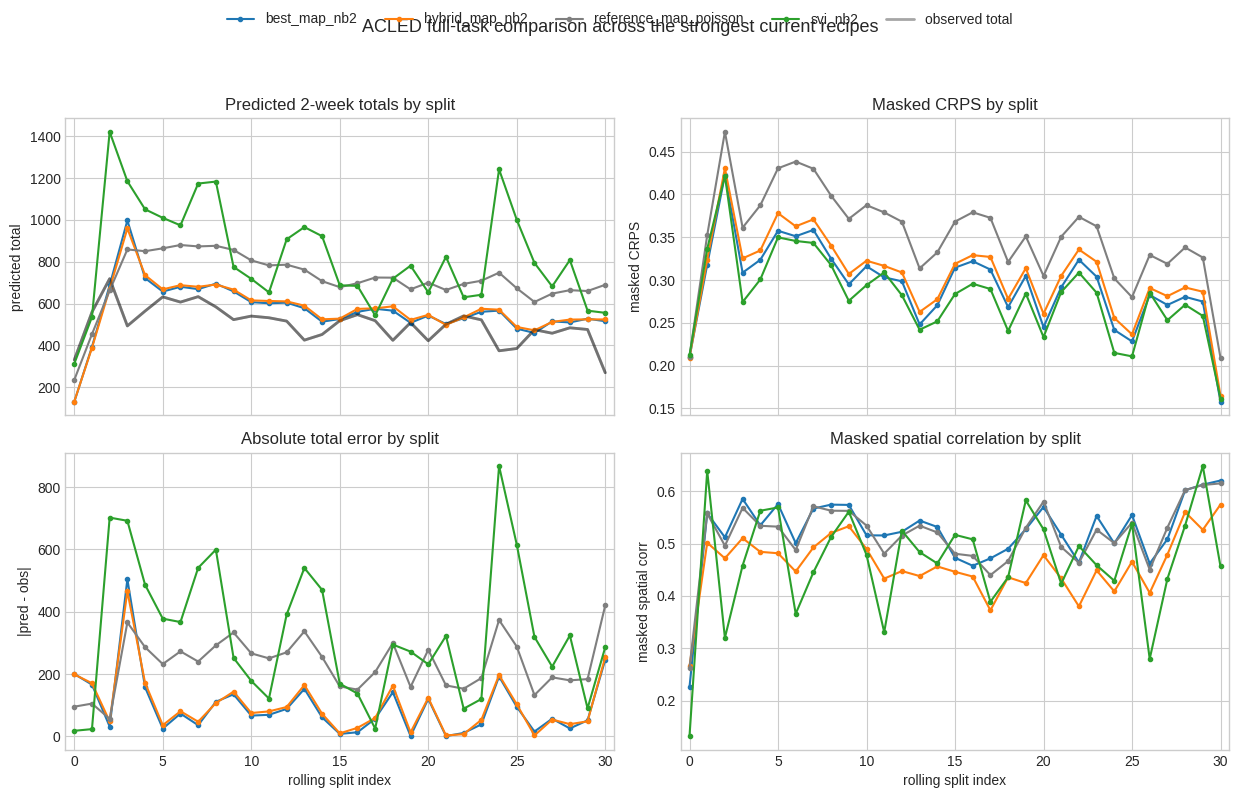

In [6]:
plot_df = summary_all[summary_all["scenario"].isin(full_task_scenarios)].copy()
scenario_colors = {
    "reference_map_poisson": "tab:gray",
    "best_map_nb2": "tab:blue",
    "svi_nb2": "tab:green",
    "hybrid_map_nb2": "tab:orange",
}

fig, axes = plt.subplots(2, 2, figsize=(12.5, 8.0), sharex=True)

for scenario, sub in plot_df.groupby("scenario"):
    color = scenario_colors.get(scenario, None)
    axes[0, 0].plot(sub["split"], sub["true_total"], color="black", linewidth=2.0, alpha=0.18)
    axes[0, 0].plot(sub["split"], sub["pred_total"], marker="o", markersize=3.0, linewidth=1.5, label=scenario, color=color)
    axes[0, 1].plot(sub["split"], sub["masked_crps"], marker="o", markersize=3.0, linewidth=1.5, label=scenario, color=color)
    axes[1, 0].plot(sub["split"], sub["abs_total_err"], marker="o", markersize=3.0, linewidth=1.5, label=scenario, color=color)
    axes[1, 1].plot(sub["split"], sub["masked_spatial_corr"], marker="o", markersize=3.0, linewidth=1.5, label=scenario, color=color)

axes[0, 0].set_title("Predicted 2-week totals by split")
axes[0, 0].set_ylabel("predicted total")
axes[0, 0].plot([], [], color="black", linewidth=2.0, alpha=0.35, label="observed total")

axes[0, 1].set_title("Masked CRPS by split")
axes[0, 1].set_ylabel("masked CRPS")

axes[1, 0].set_title("Absolute total error by split")
axes[1, 0].set_ylabel("|pred - obs|")
axes[1, 0].set_xlabel("rolling split index")

axes[1, 1].set_title("Masked spatial correlation by split")
axes[1, 1].set_ylabel("masked spatial corr")
axes[1, 1].set_xlabel("rolling split index")

for ax in axes.flat:
    ax.set_xlim(-0.5, plot_df["split"].max() + 0.5)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=max(2, len(labels)), frameon=False)
fig.suptitle("ACLED full-task comparison across the strongest current recipes", fontsize=13)
plt.tight_layout(rect=(0.0, 0.0, 1.0, 0.94))
plt.show()
plt.close(fig)

## Representative spatial forecasts

To keep this notebook short, we inspect two informative horizons:

- the split with the largest observed 2-week total
- the last split in the series

This is enough to compare the full-task winner against the main alternative posterior approximation.

/tmp/ipykernel_835470/2213300056.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=(0.0, 0.0, 1.0, 0.96))


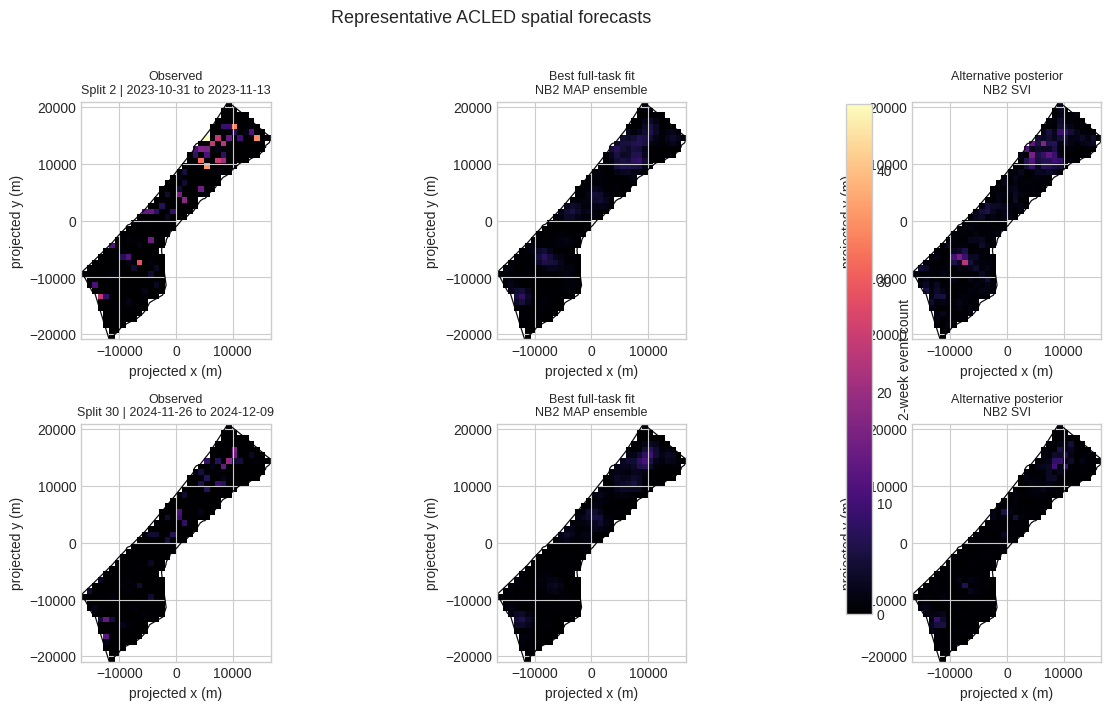

In [7]:
def plot_representative_rows(best_bt, alt_bt, *, alt_title: str, selected_split_ids: list[int]) -> None:
    best_lookup = retained_lookup(best_bt)
    alt_lookup = retained_lookup(alt_bt)
    valid_ids = [split_id for split_id in selected_split_ids if split_id in best_lookup and split_id in alt_lookup]
    if not valid_ids:
        print("No valid split ids selected for plotting.")
        return

    maps_for_scale = []
    for split_id in valid_ids:
        best_item = best_lookup[split_id]
        alt_item = alt_lookup[split_id]
        maps_for_scale.append(apply_gaza_mask(np.asarray(best_item["test_y"]).sum(axis=(0, 2)).reshape(H, W)))
        maps_for_scale.append(apply_gaza_mask(np.asarray(best_item["pred_mean"]).sum(axis=(0, 2)).reshape(H, W)))
        maps_for_scale.append(apply_gaza_mask(np.asarray(alt_item["pred_mean"]).sum(axis=(0, 2)).reshape(H, W)))
    vmax = max(max(float(np.nanmax(arr)), 1.0) for arr in maps_for_scale)

    fig, axes = plt.subplots(len(valid_ids), 3, figsize=(12.5, 3.6 * len(valid_ids)), squeeze=False)
    for row_i, split_id in enumerate(valid_ids):
        best_item = best_lookup[split_id]
        alt_item = alt_lookup[split_id]

        observed_map = apply_gaza_mask(np.asarray(best_item["test_y"]).sum(axis=(0, 2)).reshape(H, W))
        best_map = apply_gaza_mask(np.asarray(best_item["pred_mean"]).sum(axis=(0, 2)).reshape(H, W))
        alt_map = apply_gaza_mask(np.asarray(alt_item["pred_mean"]).sum(axis=(0, 2)).reshape(H, W))

        test_start = pd.Timestamp(best_item["test_t0"])
        test_end = test_start + pd.Timedelta(days=int(best_item["dt_days"])) - pd.Timedelta(days=1)
        row_label = f"Split {split_id} | {test_start.date()} to {test_end.date()}"

        im = axes[row_i, 0].imshow(observed_map, cmap="magma", vmin=0.0, vmax=vmax, origin="lower", extent=projected_extent, aspect="equal")
        axes[row_i, 1].imshow(best_map, cmap="magma", vmin=0.0, vmax=vmax, origin="lower", extent=projected_extent, aspect="equal")
        axes[row_i, 2].imshow(alt_map, cmap="magma", vmin=0.0, vmax=vmax, origin="lower", extent=projected_extent, aspect="equal")

        draw_gaza_outline_projected(axes[row_i, 0], linewidth=0.9)
        draw_gaza_outline_projected(axes[row_i, 1], linewidth=0.9)
        draw_gaza_outline_projected(axes[row_i, 2], linewidth=0.9)

        axes[row_i, 0].set_title(f"Observed\n{row_label}", fontsize=9)
        axes[row_i, 1].set_title("Best full-task fit\nNB2 MAP ensemble", fontsize=9)
        axes[row_i, 2].set_title(alt_title, fontsize=9)

        for ax in axes[row_i]:
            ax.set_xlabel("projected x (m)")
            ax.set_ylabel("projected y (m)")

    fig.colorbar(im, ax=axes, label="2-week event count", shrink=0.92)
    fig.suptitle("Representative ACLED spatial forecasts", fontsize=13)
    plt.tight_layout(rect=(0.0, 0.0, 1.0, 0.96))
    plt.show()
    plt.close(fig)


peak_split = int(best_map_bt["summary"].sort_values("true_total", ascending=False).iloc[0]["split"])
late_split = int(best_map_bt["summary"]["split"].max())
selected_spatial_splits = sorted(set([peak_split, late_split]))
plot_representative_rows(
    best_map_bt,
    svi_bt,
    alt_title="Alternative posterior\nNB2 SVI",
    selected_split_ids=selected_spatial_splits,
)

In [8]:
from motac import (
    aggregate_variant_counts_to_map,
    build_standard_acled_variants,
    flatten_variant_counts,
    summarise_variant_zero_mass,
)

variant_order = ["rect_1km", "gaza_1km", "gaza_2km"]
variant_labels = {
    "rect_1km": "1 km rectangular",
    "gaza_1km": "1 km Gaza-only",
    "gaza_2km": "2 km Gaza-only",
}

variant_dict = build_standard_acled_variants(
    events,
    marks=top_marks,
    polygon_xy=gaza_outline_xy,
    projected_extent=projected_extent,
    dt_days=14,
)

variant_zero_df = (
    pd.DataFrame([summarise_variant_zero_mass(variant_dict[name]) for name in variant_order])
    .assign(label=lambda df_: df_["variant"].map(variant_labels))
    .set_index("variant")
)

display(
    variant_zero_df[
        [
            "label",
            "cell_size_m",
            "num_grid_cells",
            "num_gaza_cells",
            "num_model_nodes",
            "zero_fraction",
            "always_zero_node_fraction",
        ]
    ].round(3)
)

,label,cell_size_m,num_grid_cells,num_gaza_cells,num_model_nodes,zero_fraction,always_zero_node_fraction
variant,,,,,,,
rect_1km,1 km rectangular,1000.0,1428.0,388.0,1428.0,0.944,0.763
gaza_1km,1 km Gaza-only,1000.0,1428.0,388.0,388.0,0.944,0.763
gaza_2km,2 km Gaza-only,2000.0,357.0,95.0,95.0,0.821,0.368


In [9]:
def run_variant_backtest(
    variant,
    *,
    scenario_name: str,
    spec: HawkesModelSpec,
    method: str,
    fit_config: FitConfig,
    min_train: int,
    forecast_samples: int,
    seed: int,
    max_splits: int | None = None,
    retain_predictions: bool = False,
):
    model = MobilityHawkesModel(spec)
    splits = variant.counts.rolling_origin_splits(horizon=1, step=1, min_train=min_train)
    if max_splits is not None:
        splits = splits[:max_splits]

    rows = []
    retained = []
    for split_id, split in enumerate(splits):
        fit = model.fit(split.train, method=method, config=fit_config, seed=seed + split_id)
        forecast = model.forecast(
            split.train,
            fit,
            horizon=1,
            num_samples=forecast_samples,
            seed=seed + 10_000 + split_id,
        )

        y_true = np.asarray(split.test.y)
        y_pred = np.asarray(forecast.mean)
        y_samples = np.asarray(forecast.y_samples)

        true_map = aggregate_variant_counts_to_map(variant, y_true)
        pred_map = aggregate_variant_counts_to_map(variant, y_pred)
        err_map = pred_map - true_map

        rows.append(
            {
                "scenario": scenario_name,
                "variant": variant.name,
                "split": split_id,
                "test_start": pd.Timestamp(split.test.t0),
                "true_total": float(y_true.sum()),
                "pred_total": float(y_pred.sum()),
                "abs_total_err": float(abs(y_pred.sum() - y_true.sum())),
                "masked_log_score": float(
                    score_predictive_log_prob_samples(
                        flatten_variant_counts(variant, y_true),
                        flatten_variant_counts(variant, y_samples),
                    )
                ),
                "masked_crps": float(
                    score_crps_counts(
                        flatten_variant_counts(variant, y_true),
                        flatten_variant_counts(variant, y_samples),
                    )
                ),
                "masked_spatial_rmse": float(np.sqrt(np.nanmean(err_map**2))),
                "masked_spatial_corr": float(safe_corr(true_map, pred_map)),
                "radius_mean": float(fit.diagnostics.get("excitation_spectral_radius_mean", np.nan)),
                "radius_subcritical": float(fit.diagnostics.get("excitation_subcritical_fraction", np.nan)),
                "num_nodes": int(variant.counts.num_nodes),
                "cell_size_m": float(variant.cell_size_m),
                "gaza_only": bool(variant.gaza_only),
            }
        )

        if retain_predictions:
            retained.append(
                {
                    "split": split_id,
                    "variant": variant.name,
                    "test_t0": pd.Timestamp(split.test.t0),
                    "dt_days": int(split.test.dt_days),
                    "test_y": y_true.astype(np.float32),
                    "pred_mean": y_pred.astype(np.float32),
                }
            )

        del fit, forecast, y_true, y_pred, y_samples, true_map, pred_map, err_map
        cleanup_memory()
        print(f"{scenario_name}: finished split {split_id + 1}/{len(splits)}")

    return {
        "scenario": scenario_name,
        "variant": variant.name,
        "summary": pd.DataFrame(rows),
        "retained": retained,
    }


variant_best_results = {}
for variant_id in variant_order:
    variant = variant_dict[variant_id]
    scenario_name = f"best_map_nb2_{variant_id}"
    variant_best_results[variant_id] = run_variant_backtest(
        variant,
        scenario_name=scenario_name,
        spec=best_spec,
        method="map_ensemble",
        fit_config=best_map_cfg,
        min_train=2,
        forecast_samples=48,
        seed=3026 + 100 * variant_order.index(variant_id),
        retain_predictions=False,
    )
    cleanup_memory()

variant_map_summary = (
    pd.concat([variant_best_results[name]["summary"] for name in variant_order], ignore_index=True)
    .groupby("variant")[["abs_total_err", "masked_log_score", "masked_crps", "masked_spatial_rmse", "masked_spatial_corr", "radius_mean", "radius_subcritical", "num_nodes"]]
    .mean()
    .assign(label=lambda df_: [variant_labels[idx] for idx in df_.index])
    .sort_values(["masked_crps", "abs_total_err"])
)

display(
    variant_map_summary[
        [
            "label",
            "num_nodes",
            "abs_total_err",
            "masked_log_score",
            "masked_crps",
            "masked_spatial_rmse",
            "masked_spatial_corr",
            "radius_mean",
            "radius_subcritical",
        ]
    ].round(3)
)

zero_followup = variant_zero_df.loc[["gaza_1km", "gaza_2km"], ["zero_fraction", "always_zero_node_fraction"]].copy()
needs_zero_heavy_extension = bool((zero_followup["always_zero_node_fraction"] > 0.5).any())
print("Zero-heavy extension recommended next:", needs_zero_heavy_extension)
print(
    "Rule used: proceed only if a Gaza-only variant still leaves more than half of model nodes always zero across the full task."
)

best_map_nb2_rect_1km: finished split 1/31
best_map_nb2_rect_1km: finished split 2/31
best_map_nb2_rect_1km: finished split 3/31
best_map_nb2_rect_1km: finished split 4/31
best_map_nb2_rect_1km: finished split 5/31
best_map_nb2_rect_1km: finished split 6/31
best_map_nb2_rect_1km: finished split 7/31
best_map_nb2_rect_1km: finished split 8/31
best_map_nb2_rect_1km: finished split 9/31
best_map_nb2_rect_1km: finished split 10/31
best_map_nb2_rect_1km: finished split 11/31
best_map_nb2_rect_1km: finished split 12/31
best_map_nb2_rect_1km: finished split 13/31
best_map_nb2_rect_1km: finished split 14/31
best_map_nb2_rect_1km: finished split 15/31
best_map_nb2_rect_1km: finished split 16/31
best_map_nb2_rect_1km: finished split 17/31
best_map_nb2_rect_1km: finished split 18/31
best_map_nb2_rect_1km: finished split 19/31
best_map_nb2_rect_1km: finished split 20/31
best_map_nb2_rect_1km: finished split 21/31
best_map_nb2_rect_1km: finished split 22/31
best_map_nb2_rect_1km: finished split 23/

,label,num_nodes,abs_total_err,masked_log_score,masked_crps,masked_spatial_rmse,masked_spatial_corr,radius_mean,radius_subcritical
variant,,,,,,,,,
rect_1km,1 km rectangular,1428.0,94.335,-0.381,0.294,3.768,0.530,0.977,0.702
gaza_1km,1 km Gaza-only,388.0,85.175,-0.433,0.352,4.351,0.178,0.969,0.798
gaza_2km,2 km Gaza-only,95.0,87.158,-1.042,1.052,8.287,0.402,1.014,0.710


Zero-heavy extension recommended next: True
Rule used: proceed only if a Gaza-only variant still leaves more than half of model nodes always zero across the full task.


## Takeaways

The main outcome from the current `motac` codebase is simple:

- the best full rolling recipe here is the tuned agnostic NB2 MAP ensemble
- SVI is worth checking because its probabilistic scores can look competitive, but in this task it tends to overshoot totals and weaken spatial fit
- the hybrid road prior is not the winner on this Gaza setup
- `nuts_small` is informative only on the earliest tiny splits and is not a practical full-task backend for this notebook

In [10]:
elapsed_sec = time.perf_counter() - NB_START
print(f"Notebook wall-clock runtime: {elapsed_sec:.2f} seconds ({elapsed_sec / 60.0:.2f} minutes)")
print("\nBest full-task scenario:", full_task_summary.index[0])
print("Best tiny-split scenario:", nuts_summary.index[0])

Notebook wall-clock runtime: 2682.32 seconds (44.71 minutes)

Best full-task scenario: reference_map_poisson
Best tiny-split scenario: nuts_small_nb2_first6
